# Hello World - Impedance Analysis
## Magnetoelastic Sensor Modeling

This notebook demonstrates the code used to model a four-branch magnetostrictive sensor viewing a ferromagentic target

**Key Topics:**
- Default sensor geometry loading
- Core permeance calculations
- Sensitivity analysis (material properties and stress effects)
- Air gap permeance
- Target permeance
- Results visualization

B. Howard

## Libraries

In [1]:
#import sys
#!{sys.executable} -m pip install subprocess

## 0. Setup and Installation

Install and verify all required libraries for this analysis.

In [2]:
import subprocess
import sys
import math

# Install required packages
required_packages = [
    'numpy',
    'pandas',
    'matplotlib',
]

print("Checking and installing required libraries...")
print("=" * 70)

for package in required_packages:
    try:
        __import__(package)
        print(f"✓ {package:12} is already installed")
    except ImportError:
        print(f"  Installing {package}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '-q'])
        print(f"✓ {package:12} installed successfully")

print("=" * 70)
print("✓ All required libraries are available!\n")

Checking and installing required libraries...
✓ numpy        is already installed
✓ pandas       is already installed
✓ matplotlib   is already installed
✓ All required libraries are available!



## 1. Import Required Libraries and Modules

In [3]:
import sys
import os

# Add parent directory to path to import magnetoelasticsensor package
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

In [4]:
# Import Required Libraries and Modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from magnetoelasticsensor.geometry import DEFAULT_SENSOR_GEOMETRY, SensorGeometry, DimensionalParameter
from magnetoelasticsensor.core_permeance import CorePermeanceModel
from magnetoelasticsensor.air_gap_permeance import AirGapPermeanceModel

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [5]:
# Configure matplotlib for PDF output with Cairo backend (or fallback)
import os
from pathlib import Path

# Create output directory for PDFs
pdf_output_dir = Path('plots_pdf')
pdf_output_dir.mkdir(exist_ok=True)

# Check for cairo backend availability and configure
pdf_backend = 'pdf'  # Default fallback
try:
    import cairo
    pdf_backend = 'cairo'
    print("✓ Cairo backend available - using for vector PDF output")
except ImportError:
    try:
        import cairocffi
        pdf_backend = 'cairo'
        print("✓ CairoCFFI backend available - using for vector PDF output")
    except ImportError:
        print("⚠ Cairo/CairoCFFI not available - using native PDF backend (vector-based)")

# Enable PDF output with vector graphics
plt.rcParams['pdf.fonttype'] = 42  # Use TrueType fonts in PDFs
plt.rcParams['ps.fonttype'] = 42

# Helper function to generate smart filenames for plots
def generate_pdf_filename(section_name, plot_name):
    """
    Generate a smart PDF filename based on section and plot names.
    Converts spaces and special characters to underscores, removes extra dots.
    
    Parameters
    ----------
    section_name : str
        Section identifier (e.g., '6.1', '7.0')
    plot_name : str
        Descriptive plot name (e.g., 'target_permeance_vs_frequency')
    
    Returns
    -------
    Path
        Full path to the output PDF file
    """
    # Sanitize names: replace spaces and special chars with underscores
    section_clean = section_name.replace('.', '_').strip()
    plot_clean = plot_name.lower().replace(' ', '_').replace('-', '_')
    plot_clean = ''.join(c if c.isalnum() or c == '_' else '' for c in plot_clean)
    
    filename = f"section_{section_clean}_{plot_clean}.pdf"
    return pdf_output_dir / filename

def save_plot_pdf(fig, section_name, plot_name, dpi=300):
    """
    Save a matplotlib figure as a vector-based PDF file.
    
    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object to save
    section_name : str
        Section identifier (e.g., '6.1')
    plot_name : str
        Descriptive plot name
    dpi : int
        DPI for rasterization (default 300 for high quality)
    """
    pdf_path = generate_pdf_filename(section_name, plot_name)
    # Save as PDF using the configured backend
    fig.savefig(pdf_path, format='pdf', dpi=dpi, bbox_inches='tight')
    print(f"✓ PDF saved: {pdf_path}")
    return pdf_path

print(f"✓ PDF output directory: {pdf_output_dir.absolute()}")
print(f"✓ Smart filename generator and PDF saver ready\n")


✓ Cairo backend available - using for vector PDF output
✓ PDF output directory: C:\Local Docs\Github\MagnetoelasticSensor\notebooks\plots_pdf
✓ Smart filename generator and PDF saver ready



## 2. Load Default Geometry Parameters

The default sensor geometry represents the specification for the magnetoelastic sensor architecture. All dimensions are in SI units (meters) with manufacturing tolerances.

[![Four‑Branch Geometry](https://robotsquirrelproductions.com/wp-content/uploads/2026/02/Four-Branch-Geo-00_2k_240818_071759.png)](https://robotsquirrelproductions.com/wp-content/uploads/2026/02/Four-Branch-Geo-00_2k_240818_071759.png)

In [6]:
# Load and display default geometry
geom = DEFAULT_SENSOR_GEOMETRY

print("DEFAULT SENSOR GEOMETRY")
print("=" * 70)
print(geom)
print("\n")

# Display geometry parameters in tabular format
geometry_data = {
    'Component': [
        'Drive Pole', 'Drive Pole',
        'Sense Pole', 'Sense Pole',
        'Bridge (Arm)', 'Bridge (Arm)', 'Bridge (Arm)',
        'Pole Gap'
    ],
    'Parameter': [
        'Diameter (dim_dp)', 'Height (dim_sph_drive)',
        'Diameter (dim_sp)', 'Height (dim_sph_sense)',
        'Width (dim_spaw)', 'Height (dim_spah)', 'Length (dim_spac)',
        'Distance (dim_spag)'
    ],
    'Nominal [mm]': [
        geom.dim_dp.nominal * 1e3, geom.dim_sph_drive.nominal * 1e3,
        geom.dim_sp.nominal * 1e3, geom.dim_sph_sense.nominal * 1e3,
        geom.dim_spaw.nominal * 1e3, geom.dim_spah.nominal * 1e3, geom.dim_spac.nominal * 1e3,
        geom.dim_spag.nominal * 1e3
    ],
    'Tolerance [mm]': [
        geom.dim_dp.tolerance * 1e3, geom.dim_sph_drive.tolerance * 1e3,
        geom.dim_sp.tolerance * 1e3, geom.dim_sph_sense.tolerance * 1e3,
        geom.dim_spaw.tolerance * 1e3, geom.dim_spah.tolerance * 1e3, geom.dim_spac.tolerance * 1e3,
        geom.dim_spag.tolerance * 1e3
    ],
    'Min [mm]': [
        geom.dim_dp.min * 1e3, geom.dim_sph_drive.min * 1e3,
        geom.dim_sp.min * 1e3, geom.dim_sph_sense.min * 1e3,
        geom.dim_spaw.min * 1e3, geom.dim_spah.min * 1e3, geom.dim_spac.min * 1e3,
        geom.dim_spag.min * 1e3
    ],
    'Max [mm]': [
        geom.dim_dp.max * 1e3, geom.dim_sph_drive.max * 1e3,
        geom.dim_sp.max * 1e3, geom.dim_sph_sense.max * 1e3,
        geom.dim_spaw.max * 1e3, geom.dim_spah.max * 1e3, geom.dim_spac.max * 1e3,
        geom.dim_spag.max * 1e3
    ]
}

df_geometry = pd.DataFrame(geometry_data)
print(df_geometry.to_string(index=False))
print("\n")

DEFAULT SENSOR GEOMETRY
SensorGeometry(
  Drive pole:     ∅ 9.50mm × H 15.00mm
  Sense pole:     ∅ 4.50mm × H 15.00mm
  Bridge (arm):   W 4.50mm × H 4.25mm × L 16.00mm
  Pole gap:       9.00mm
)


   Component              Parameter  Nominal [mm]  Tolerance [mm]  Min [mm]  Max [mm]
  Drive Pole      Diameter (dim_dp)          9.50            0.08      9.42      9.58
  Drive Pole Height (dim_sph_drive)         15.00            0.08     14.92     15.08
  Sense Pole      Diameter (dim_sp)          4.50            0.08      4.42      4.58
  Sense Pole Height (dim_sph_sense)         15.00            0.08     14.92     15.08
Bridge (Arm)       Width (dim_spaw)          4.50            0.08      4.42      4.58
Bridge (Arm)      Height (dim_spah)          4.25            0.08      4.17      4.33
Bridge (Arm)      Length (dim_spac)         16.00            0.08     15.92     16.08
    Pole Gap    Distance (dim_spag)          9.00            0.10      8.90      9.10




## 3. Calculate Core Permeance

We calculate core permeance for various scenarios:
1. **Baseline**: Nominal target permeability (μᵣ = 1000), unstressed
2. **Material Variation**: Different ferromagnetic materials
3. **Stress Variation**: Tensile and compressive stress effects

In [7]:
# Calculate baseline permeance
model = CorePermeanceModel(geom)
baseline_permeance = model.calculate_core_permeance()

print("BASELINE CORE PERMEANCE")
print("=" * 70)
print(f"Target permeability (μᵣ):  1000.0 (ferromagnetic)")
print(f"Applied stress:            0.0 Pa (unstressed)")
print(f"Core Permeance (𝒫_core):   {baseline_permeance:.6e} H")
print(f"                           {baseline_permeance*1e9:.4f} nH")
print("\n")

BASELINE CORE PERMEANCE
Target permeability (μᵣ):  1000.0 (ferromagnetic)
Applied stress:            0.0 Pa (unstressed)
Core Permeance (𝒫_core):   1.261860e-06 H
                           1261.8601 nH




In [8]:
# Scenario 1: Core Permeance Variation Analysis
# How does the core permeance change with temperature?

# Values from:
# “97 Material Data Sheet - Fair-Rite.” Fair-Rite 97 Material Data 
# Sheet, Fair-rite, 26 Apr. 2023, fair-rite.com/97-material-data-sheet/.
temperature_scenarios = {
    '  -50°C': 1200.0,
    '  -20°C': 1500.0,
    '  +20°C': 2000.0,
    ' +100°C': 4050.0,
    ' +240°C': 5.0,
}

temperature_results = []

for temperature_name, mu_r in temperature_scenarios.items():
    permeance = model.calculate_core_permeance(mur=mu_r, omega=50000*math.pi*2)
    temperature_results.append({
        'Material': temperature_name,
        'μᵣ': mu_r,
        'Permeance [H]': permeance,
        'Permeance [nH]': permeance * 1e9,
        'Relative to Baseline': permeance / baseline_permeance
    })

df_materials = pd.DataFrame(temperature_results)

print("SCENARIO 1: CORE EQUIVALENT PERMEABILITY VARIATION TO TEMPERATURE")
print("=" * 70)
print(df_materials.to_string(index=False))
print("\n")

SCENARIO 1: CORE EQUIVALENT PERMEABILITY VARIATION TO TEMPERATURE
Material     μᵣ  Permeance [H]  Permeance [nH]  Relative to Baseline
   -50°C 1200.0   7.571710e-07      757.170971              0.600044
   -20°C 1500.0   9.464380e-07      946.437960              0.750034
   +20°C 2000.0   1.261860e-06     1261.860055              1.000000
  +100°C 4050.0   2.554792e-06     2554.791606              2.024624
  +240°C    5.0   3.155221e-09        3.155221              0.002500




## 4. Calculate Air Gap Permeance
Compute baseline air gap permeance and evaluate sensitivity to drive pole and sense pole gap distances.

![C‑Core Flux](https://robotsquirrelproductions.com/wp-content/uploads/2026/02/C-Core-Flux-00_2k_260202_080546.png)

In [ ]:
# Baseline air gap permeance
air_gap_model = AirGapPermeanceModel(geom)
baseline_air_gap = air_gap_model.calculate_air_gap_permeance()

print("BASELINE AIR GAP PERMEANCE")
print("=" * 70)
print(f"Sense pole gap:           {geom.avg_gap.nominal*1e3:.3f} mm")
print(f"Drive pole gap:           {geom.avg_gap.nominal*1e3:.3f} mm")
print(f"Air Gap Permeance (sense): {baseline_air_gap[0]:.6e} H")
print(f"Air Gap Permeance (drive): {baseline_air_gap[1]:.6e} H")
print("\n")

# Sensitivity to drive/sense pole gap distance
drive_gap_mm = np.array([0.25, 0.50, 0.75, 1.00, 1.143, 1.25, 1.50])
sense_gap_mm = np.array([0.25, 0.50, 0.75, 1.00, 1.143, 1.25, 1.50])
drive_gap_m = drive_gap_mm * 1e-3
sense_gap_m = sense_gap_mm * 1e-3

gap_results = []
for d_gap, s_gap in zip(drive_gap_m, sense_gap_m):
    p_sense, p_drive = air_gap_model.calculate_air_gap_permeance(
        drive_pole_gap=d_gap,
        sense_pole_gap=s_gap,
    )
    gap_results.append({
        "Drive Gap [mm]": d_gap * 1e3,
        "Sense Gap [mm]": s_gap * 1e3,
        "𝒫_gap_sense [H]": p_sense,
        "𝒫_gap_drive [H]": p_drive,
        "Sense vs Baseline": p_sense / baseline_air_gap[0],
        "Drive vs Baseline": p_drive / baseline_air_gap[1],
    })

df_gap = pd.DataFrame(gap_results)
print("AIR GAP PERMEANCE VS DRIVE/SENSE GAP DISTANCE")
print("=" * 70)
print(df_gap.to_string(index=False))
print("\n")

BASELINE AIR GAP PERMEANCE
Average gap:               1.143 mm
Air Gap Permeance (sense): 4.799748e-08 H
Air Gap Permeance (drive): 1.304100e-07 H


AIR GAP PERMEANCE VS GAP DISTANCE
 Gap [mm]  𝒫_gap_sense [H]  𝒫_gap_drive [H]  Sense vs Baseline  Drive vs Baseline
    0.250     1.278014e-07     4.452193e-07           2.662668           3.413996
    0.500     8.063857e-08     2.511717e-07           1.680058           1.926015
    0.750     6.262275e-08     1.820025e-07           1.304709           1.395618
    1.000     5.230831e-08     1.450439e-07           1.089814           1.112214
    1.143     4.799748e-08     1.304100e-07           1.000000           1.000000
    1.250     4.524292e-08     1.213569e-07           0.942610           0.930580
    1.500     3.989042e-08     1.045017e-07           0.831094           0.801332




## 5.0 Cross-Leakage Flux Model

This section exercises the cross-leakage permeance model and compares a baseline
configuration to a wider pole spacing scenario.

![C‑Core Cross-Leakage Flux](https://robotsquirrelproductions.com/wp-content/uploads/2026/02/C-Core-Flux-C-Core-CrossLeakage-Flux-00_2k_260202_080546-1.png)

In [10]:
import copy
from magnetoelasticsensor.cross_leakage_permeance import CrossLeakagePermeanceModel

cross_leakage_model = CrossLeakagePermeanceModel()
baseline_cross_leakage = cross_leakage_model.calculate_cross_leakage_permeance()

print("Cross-leakage permeance (baseline):", baseline_cross_leakage)

# Demonstrate sensitivity to pole spacing by adjusting dim_spag
geom_wide_gap = copy.deepcopy(DEFAULT_SENSOR_GEOMETRY)
geom_wide_gap.dim_spag.nominal *= 1.2

wide_gap_model = CrossLeakagePermeanceModel(geometry=geom_wide_gap)
wide_gap_permeance = wide_gap_model.calculate_cross_leakage_permeance()

print("Cross-leakage permeance (wider pole spacing):", wide_gap_permeance)
print("Ratio (wide/baseline):", wide_gap_permeance / baseline_cross_leakage)

Cross-leakage permeance (baseline): 2.329754661984131e-08
Cross-leakage permeance (wider pole spacing): 2.0250387858168473e-08
Ratio (wide/baseline): 0.8692068821067309


## 6.0 Target Eddy Current Skin Depth

This section analyzes how the eddy current skin depth in the target material varies 
with operating frequency. Skin depth determines the effective depth of magnetic 
penetration into the ferromagnetic target and is critical for sensor sensitivity 
at different frequencies.

In [11]:
import numpy as np
import pandas as pd
import importlib
import sys

# Reload the permeance module to pick up the calculate_skin_depth function
if 'magnetoelasticsensor.permeance' in sys.modules:
    import magnetoelasticsensor.permeance
    importlib.reload(magnetoelasticsensor.permeance)

from magnetoelasticsensor.permeance import calculate_skin_depth

# Define a range of operating frequencies (10 kHz to 500 kHz)
frequencies_hz = np.array([10, 20, 50, 100, 200, 500]) * 1e3  # Hz
frequencies_khz = frequencies_hz / 1e3  # kHz for display

# Convert to angular frequency (rad/s)
omegas = 2 * np.pi * frequencies_hz

# Target material parameters (ferromagnetic steel)
muo = DEFAULT_SENSOR_GEOMETRY.muo.nominal
murt = DEFAULT_SENSOR_GEOMETRY.murt.nominal  # Target permeability
# Conductivity is reciprocal of resistivity (S/m)
sigma_c = DEFAULT_SENSOR_GEOMETRY.sigmac.nominal  # Conductivity of ferromagnetic target [S/m]

# Calculate skin depth for each frequency
skin_depths = []
for omega in omegas:
    delta = calculate_skin_depth(muo=muo, mur=murt, omega=omega, sigma_c=sigma_c)
    skin_depths.append(delta * 1e6)  # Convert to micrometers

# Create results dataframe
skin_depth_results = pd.DataFrame({
    'Frequency (kHz)': frequencies_khz,
    'Skin Depth (μm)': skin_depths,
    'Skin Depth (mm)': [d / 1e3 for d in skin_depths],
})

print("Eddy Current Skin Depth vs Operating Frequency")
print("=" * 60)
print(skin_depth_results.to_string(index=False))



Eddy Current Skin Depth vs Operating Frequency
 Frequency (kHz)  Skin Depth (μm)  Skin Depth (mm)
            10.0       304.758514         0.304759
            20.0       215.496812         0.215497
            50.0       136.292151         0.136292
           100.0        96.373104         0.096373
           200.0        68.146075         0.068146
           500.0        43.099362         0.043099


## 6.1 Target Permeance vs Operating Frequency

This section evaluates the target permeance and shows how it varies with drive frequency. The calculation uses the same frequency sweep as the skin depth analysis.

Target Permeance vs Operating Frequency
 Frequency (kHz)  Target Permeance (H)  Target Permeance (nH)  Target Eddy-Current Permeance (H)  Target Eddy-Current Permeance (nH)
            10.0          4.718626e-08              47.186263                       3.765240e-09                            3.765240
            20.0          3.336573e-08              33.365727                       2.662426e-09                            2.662426
            50.0          2.110234e-08              21.102338                       1.683866e-09                            1.683866
           100.0          1.492161e-08              14.921607                       1.190673e-09                            1.190673
           200.0          1.055117e-08              10.551169                       8.419332e-10                            0.841933
           500.0          6.673145e-09               6.673145                       5.324853e-10                            0.532485


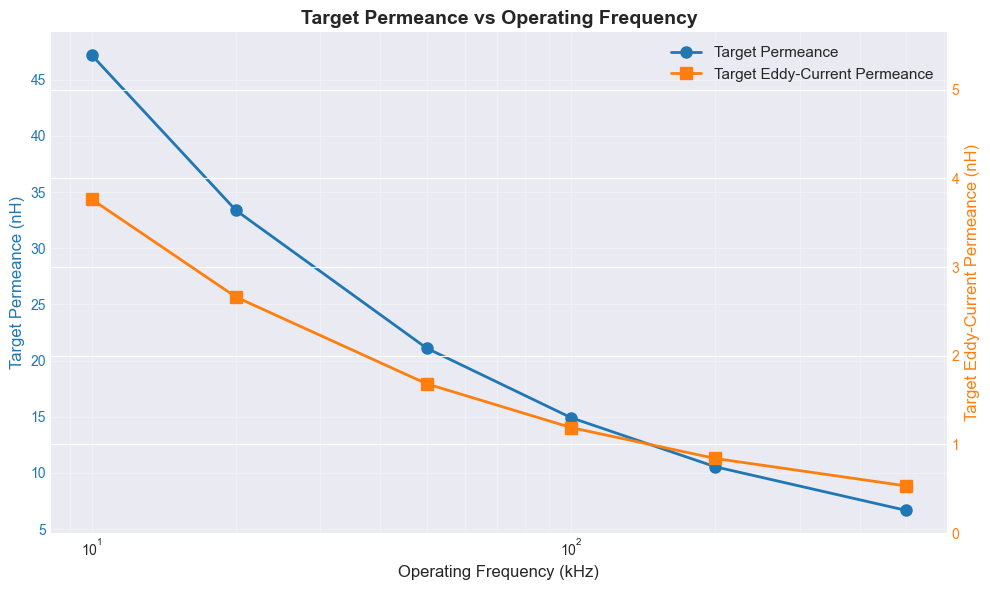

✓ PDF saved: plots_pdf\section_6_1_target_permeance_vs_frequency.pdf

Permeance range: 6.673 - 47.186 nH


In [12]:
import importlib
import sys
from magnetoelasticsensor.permeance import cross_leakage_u_parameter

# Reload target_permeance module to pick up recent changes
if 'magnetoelasticsensor.target_permeance' in sys.modules:
    import magnetoelasticsensor.target_permeance
    importlib.reload(magnetoelasticsensor.target_permeance)

from magnetoelasticsensor.target_permeance import calculate_target_permeance

# Geometry-based u parameter for target permeance
u_target = cross_leakage_u_parameter(
    dim_spagi=geom.dim_spag.nominal,
    dim_dp=geom.dim_dp.nominal,
    dim_spi=geom.dim_sp.nominal,
)

# Compute target permeance over frequency sweep
p3_results = []
p3_results_eddy = []
for omega in omegas:
    p3 = calculate_target_permeance(
        geometry=geom,
        u=u_target,
        sigma_c=sigma_c,
        omega=omega,
    )
    # Extract scalar value from result (handles arrays, lists, scalars)
    p3_results.append(float(np.asarray(p3).flat[0]))
    p3_results_eddy.append(float(np.asarray(p3).flat[1]))

# Convert to 1D numpy array
p3_results = np.array(p3_results)
p3_results_eddy = np.array(p3_results_eddy)

# Create results dataframe
p3_df = pd.DataFrame({
    'Frequency (kHz)': frequencies_khz,
    'Target Permeance (H)': p3_results,
    'Target Permeance (nH)': p3_results * 1e9,
    'Target Eddy-Current Permeance (H)': p3_results_eddy,
    'Target Eddy-Current Permeance (nH)': p3_results_eddy * 1e9,
})

print("Target Permeance vs Operating Frequency")
print("=" * 60)
print(p3_df.to_string(index=False))

# Plot target permeance vs frequency with dual y-axes
fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogx(frequencies_khz, p3_results * 1e9, 'o-', linewidth=2, markersize=8, label='Target Permeance', color='C0')
ax.set_xlabel('Operating Frequency (kHz)', fontsize=12)
ax.set_ylabel('Target Permeance (nH)', fontsize=12, color='C0')
ax.tick_params(axis='y', labelcolor='C0')

# Create secondary y-axis on the right
ax2 = ax.twinx()
ax2.semilogx(frequencies_khz, p3_results_eddy * 1e9, 's-', linewidth=2, markersize=8, label='Target Eddy-Current Permeance', color='C1')
ax2.set_ylabel('Target Eddy-Current Permeance (nH)', fontsize=12, color='C1')
ax2.tick_params(axis='y', labelcolor='C1')
ax2.set_ylim(0, max(p3_results_eddy)*1e9*1.5)  # Set y-axis limit for better visualization

ax.set_title('Target Permeance vs Operating Frequency', fontsize=14, fontweight='bold')
ax.grid(True, which='both', alpha=0.3)

# Combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

# Save as PDF with smart filename
save_plot_pdf(fig, '6.1', 'Target_Permeance_vs_Frequency')

print(f"\nPermeance range: {p3_results.min()*1e9:.3f} - {p3_results.max()*1e9:.3f} nH")


## 6.2 Effective and Equivalent Permeance Calculations

This section calculates the effective permeance of series elements and the equivalent permeance of the complete four-branch magnetic circuit, demonstrating how different permeance components combine to affect overall sensor response.

EFFECTIVE PERMEANCE (Series: Target + Air Gaps)
Target permeance (P_t):        2.110234e-08 H (21.102 nH)
Drive gap permeance (P_gapd):  1.304100e-07 H (130.410 nH)
Sense gap permeance (P_gaps):  4.799748e-08 H (47.997 nH)

Effective permeance (P_eff):   1.317685e-08 H (13.177 nH)


EQUIVALENT PERMEANCE (Four-Branch Circuit)
Core permeance (P_core):           1.261860e-06 H (1261.860 nH)
Effective permeance (P_eff):       1.317685e-08 H (13.177 nH)
Cross-leakage permeance (P_sd):    2.329755e-08 H (23.298 nH)

Equivalent permeance (P_eq):       2.060080e-08 H (20.601 nH)
Relative to core permeance:        1.6%
Relative to effective permeance:   156.3%


PERMEANCE VALUES ACROSS FREQUENCY SWEEP
 Frequency (kHz)  Effective Permeance (nH)  Equivalent Permeance (nH)  P_eq / P_core (%)
            10.0                 20.122686                  27.285494           2.162323
            20.0                 17.101787                  24.387037           1.932626
            50.0               

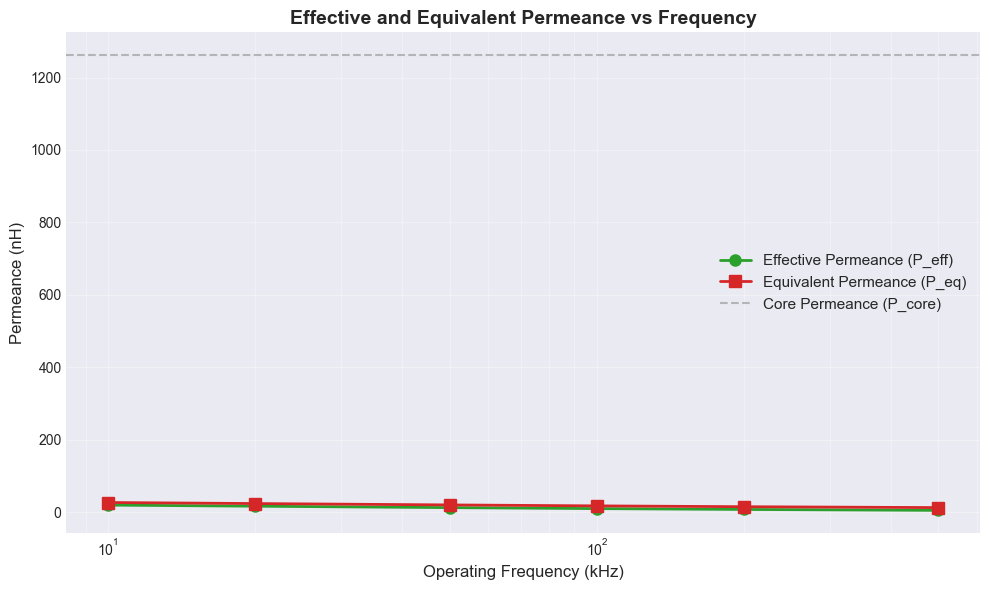

✓ PDF saved: plots_pdf\section_6_2_effective_equivalent_permeance_vs_frequency.pdf

Effective permeance range: 5.607 - 20.123 nH
Equivalent permeance range: 13.232 - 27.285 nH


In [13]:
import importlib
import sys

# Reload permeance module to ensure we have the new functions
if 'magnetoelasticsensor.permeance' in sys.modules:
    import magnetoelasticsensor.permeance
    importlib.reload(magnetoelasticsensor.permeance)

from magnetoelasticsensor.permeance import (
    calculate_effective_permeance,
    calculate_equivalent_permeance
)

# Calculate effective permeance (series combination of target and air gaps)
# Using baseline values at nominal frequency
nominal_freq_idx = 2  # 50 kHz index

p_target = p3_results[nominal_freq_idx]
p_gap_sense = baseline_air_gap[0]
p_gap_drive = baseline_air_gap[1]

p_effective = calculate_effective_permeance(
    pt=p_target,
    p_gapd=p_gap_drive,
    p_gaps=p_gap_sense
)

print("EFFECTIVE PERMEANCE (Series: Target + Air Gaps)")
print("=" * 70)
print(f"Target permeance (P_t):        {p_target:.6e} H ({p_target*1e9:.3f} nH)")
print(f"Drive gap permeance (P_gapd):  {p_gap_drive:.6e} H ({p_gap_drive*1e9:.3f} nH)")
print(f"Sense gap permeance (P_gaps):  {p_gap_sense:.6e} H ({p_gap_sense*1e9:.3f} nH)")
print(f"\nEffective permeance (P_eff):   {p_effective:.6e} H ({p_effective*1e9:.3f} nH)")
print("\n")

# Calculate equivalent permeance for the complete four-branch circuit
# Using core permeance, effective permeance, and cross-leakage
p_eq = calculate_equivalent_permeance(
    p_core=baseline_permeance,
    p=p_effective,
    p_sd=baseline_cross_leakage
)

print("EQUIVALENT PERMEANCE (Four-Branch Circuit)")
print("=" * 70)
print(f"Core permeance (P_core):           {baseline_permeance:.6e} H ({baseline_permeance*1e9:.3f} nH)")
print(f"Effective permeance (P_eff):       {p_effective:.6e} H ({p_effective*1e9:.3f} nH)")
print(f"Cross-leakage permeance (P_sd):    {baseline_cross_leakage:.6e} H ({baseline_cross_leakage*1e9:.3f} nH)")
print(f"\nEquivalent permeance (P_eq):       {p_eq:.6e} H ({p_eq*1e9:.3f} nH)")
print(f"Relative to core permeance:        {100 * p_eq / baseline_permeance:.1f}%")
print(f"Relative to effective permeance:   {100 * p_eq / p_effective:.1f}%")
print("\n")

# Calculate equivalent permeance across frequency sweep
p_eq_results = []
p_eff_results = []

for i, omega in enumerate(omegas):
    # Effective permeance at each frequency
    p_eff = calculate_effective_permeance(
        pt=p3_results[i],
        p_gapd=p_gap_drive,
        p_gaps=p_gap_sense
    )
    p_eff_results.append(p_eff)
    
    # Equivalent permeance at each frequency
    p_eq_freq = calculate_equivalent_permeance(
        p_core=baseline_permeance,
        p=p_eff,
        p_sd=baseline_cross_leakage
    )
    p_eq_results.append(p_eq_freq)

p_eff_results = np.array(p_eff_results)
p_eq_results = np.array(p_eq_results)

# Create results dataframe
peq_df = pd.DataFrame({
    'Frequency (kHz)': frequencies_khz,
    'Effective Permeance (nH)': p_eff_results * 1e9,
    'Equivalent Permeance (nH)': p_eq_results * 1e9,
    'P_eq / P_core (%)': 100 * p_eq_results / baseline_permeance,
})

print("PERMEANCE VALUES ACROSS FREQUENCY SWEEP")
print("=" * 70)
print(peq_df.to_string(index=False))
print("\n")

# Plot effective and equivalent permeance vs frequency
fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogx(frequencies_khz, p_eff_results * 1e9, 'o-', linewidth=2, markersize=8, label='Effective Permeance (P_eff)', color='C2')
ax.semilogx(frequencies_khz, p_eq_results * 1e9, 's-', linewidth=2, markersize=8, label='Equivalent Permeance (P_eq)', color='C3')
ax.axhline(y=baseline_permeance*1e9, color='gray', linestyle='--', alpha=0.5, label='Core Permeance (P_core)')

ax.set_xlabel('Operating Frequency (kHz)', fontsize=12)
ax.set_ylabel('Permeance (nH)', fontsize=12)
ax.set_title('Effective and Equivalent Permeance vs Frequency', fontsize=14, fontweight='bold')
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

# Save as PDF with smart filename
save_plot_pdf(fig, '6.2', 'Effective_Equivalent_Permeance_vs_Frequency')

print(f"\nEffective permeance range: {p_eff_results.min()*1e9:.3f} - {p_eff_results.max()*1e9:.3f} nH")
print(f"Equivalent permeance range: {p_eq_results.min()*1e9:.3f} - {p_eq_results.max()*1e9:.3f} nH")


## 7.0 Transimpedance Analysis

The transimpedance of a magnetoelastic sensor represents the ratio of sense coil voltage to drive coil current (Z = Vs/Id). This is a complex quantity that depends on:

1. **Normalized Impedance (z)**: A dimensionless factor describing the magnetic circuit impedance response, accounting for permeance relationships and damping effects
2. **Transimpedance (Z)**: The physical impedance in Ohms, incorporating coil turns and operating frequency

### Key Physics:
- The damping factor (epsilon, ε = tan θ₃) characterizes the phase relationship between stress and permeability change
- Cross-leakage permeance (P_sd) affects signal coupling between drive and sense branches
- Operating frequency (ω) influences eddy current effects in the target material
- Coil turn counts (N_drive, N_sense) determine electromagnetic coupling efficiency

In [14]:
import importlib
import sys
import cmath

# Reload geometry module first since it was updated with new parameters
if 'magnetoelasticsensor.geometry' in sys.modules:
    import magnetoelasticsensor.geometry
    importlib.reload(magnetoelasticsensor.geometry)
    from magnetoelasticsensor.geometry import DEFAULT_SENSOR_GEOMETRY

# Reload transimpedance module to ensure we have the latest functions
if 'magnetoelasticsensor.transimpedance' in sys.modules:
    import magnetoelasticsensor.transimpedance
    importlib.reload(magnetoelasticsensor.transimpedance)

from magnetoelasticsensor.transimpedance import (
    calculate_normalized_impedance,
    calculate_transimpedance,
    calculate_transimpedance_magnitude,
    calculate_transimpedance_phase,
)

# Calculate normalized impedance using baseline geometry and permeances
eta = math.tan(math.radians(DEFAULT_SENSOR_GEOMETRY.theta3_deg.nominal))

z = calculate_normalized_impedance(
    p3=p3_results[nominal_freq_idx],
    p_sd=baseline_cross_leakage,
    p=p_eff_results[nominal_freq_idx],
    epsilon=eta
)

print("NORMALIZED IMPEDANCE (Dimensionless)")
print("=" * 70)
print(f"Operating frequency:           50 kHz")
print(f"Damping factor (ε = tan θ₃):   {eta:.6f}")
print(f"Target permeance (P₃):         {p3_results[nominal_freq_idx]*1e9:.3f} nH")
print(f"Cross-leakage permeance:       {baseline_cross_leakage*1e9:.3f} nH")
print(f"Effective permeance:           {p_eff_results[nominal_freq_idx]*1e9:.3f} nH")
print(f"\nNormalized Impedance (z):")
print(f"  Real part:    {z.real:.6f}")
print(f"  Imaginary:    {z.imag:.6f}")
print(f"  Magnitude:    {abs(z):.6f}")
print(f"  Phase (rad):  {cmath.phase(z):.6f}")
print(f"  Phase (deg):  {math.degrees(cmath.phase(z)):.3f}°")
print("\n")

NORMALIZED IMPEDANCE (Dimensionless)
Operating frequency:           50 kHz
Damping factor (ε = tan θ₃):   1.000000
Target permeance (P₃):         21.102 nH
Cross-leakage permeance:       23.298 nH
Effective permeance:           13.177 nH

Normalized Impedance (z):
  Real part:    1.310597
  Imaginary:    -0.171604
  Magnitude:    1.321784
  Phase (rad):  -0.130195
  Phase (deg):  -7.460°




TRANSIMPEDANCE FREQUENCY RESPONSE
Drive coil turns (Nd):         60
Sense coil turns (Ns):         100
Damping factor (ε):            1.000000
Cross-leakage permeance:       23.298 nH


 Frequency (kHz)  Transimpedance Magnitude (Ω)  Transimpedance Phase (rad)  Transimpedance Phase (deg)
            10.0                     12.279647                    1.452810                   83.239903
            20.0                     22.583941                    1.443526                   82.707970
            50.0                     51.326970                    1.440601                   82.540368
           100.0                     98.026659                    1.445965                   82.847715
           200.0                    193.726838                    1.456911                   83.474854
           500.0                    509.226849                    1.476836                   84.616452




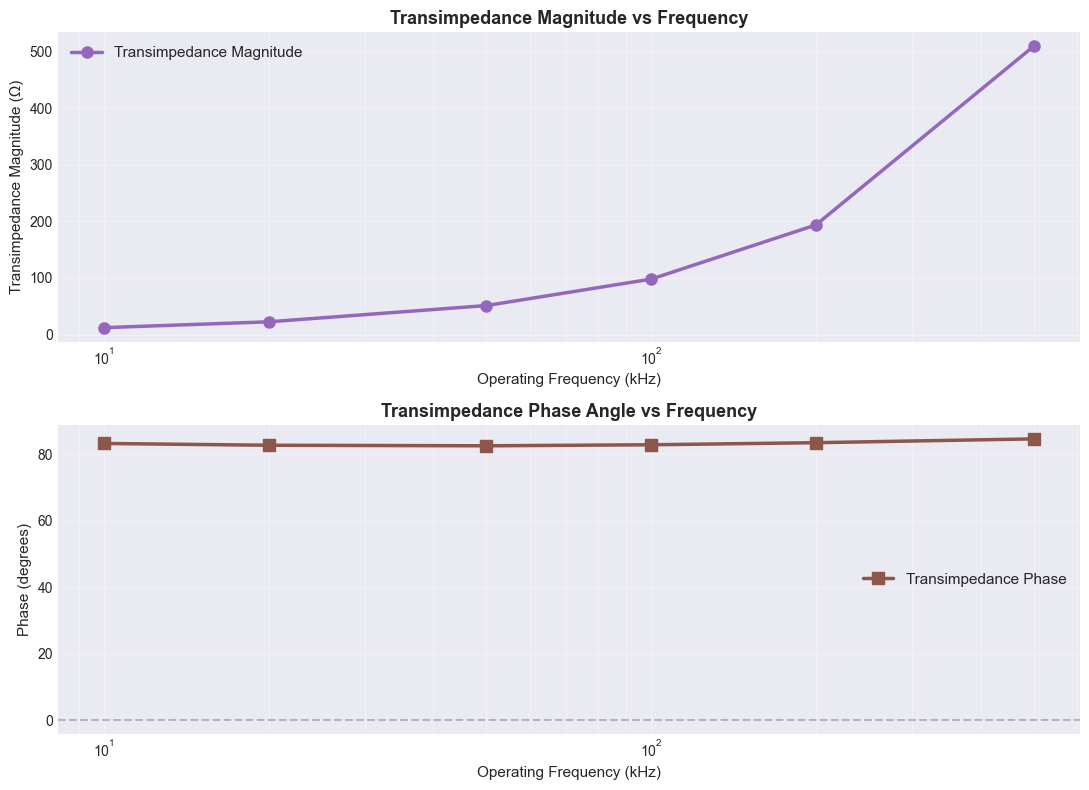

✓ PDF saved: plots_pdf\section_7_0_transimpedance_frequency_response.pdf

Transimpedance magnitude range: 12.280 - 509.227 Ω
Transimpedance phase range:     82.5° - 84.6°




In [15]:
# Calculate transimpedance across frequency range with default geometry
nd = int(DEFAULT_SENSOR_GEOMETRY.ndrive.nominal)
ns = int(DEFAULT_SENSOR_GEOMETRY.nsense.nominal)
eta = math.tan(math.radians(DEFAULT_SENSOR_GEOMETRY.theta3_deg.nominal))

print("TRANSIMPEDANCE FREQUENCY RESPONSE")
print("=" * 70)
print(f"Drive coil turns (Nd):         {nd}")
print(f"Sense coil turns (Ns):         {ns}")
print(f"Damping factor (ε):            {eta:.6f}")
print(f"Cross-leakage permeance:       {baseline_cross_leakage*1e9:.3f} nH")
print("\n")

# Calculate transimpedance (magnitude and phase) across frequency sweep
z_magnitude_results = []
z_phase_results = []
z_complex_results = []

for i, omega in enumerate(omegas):
    # Calculate full transimpedance
    Z = calculate_transimpedance(
        nd=nd,
        ns=ns,
        p_eq=p_eq_results[i],
        omega=omega,
        p3=p3_results[i],
        p_sd=baseline_cross_leakage,
        p=p_eff_results[i],
        epsilon=eta
    )
    
    Z_mag = calculate_transimpedance_magnitude(
        nd=nd,
        ns=ns,
        p_eq=p_eq_results[i],
        omega=omega,
        p3=p3_results[i],
        p_sd=baseline_cross_leakage,
        p=p_eff_results[i],
        epsilon=eta
    )
    
    Z_phase = calculate_transimpedance_phase(
        nd=nd,
        ns=ns,
        p_eq=p_eq_results[i],
        omega=omega,
        p3=p3_results[i],
        p_sd=baseline_cross_leakage,
        p=p_eff_results[i],
        epsilon=eta
    )
    
    z_complex_results.append(Z)
    z_magnitude_results.append(Z_mag)
    z_phase_results.append(Z_phase)

z_magnitude_results = np.array(z_magnitude_results)
z_phase_results = np.array(z_phase_results)

# Create results dataframe
transimpedance_df = pd.DataFrame({
    'Frequency (kHz)': frequencies_khz,
    'Transimpedance Magnitude (Ω)': z_magnitude_results,
    'Transimpedance Phase (rad)': z_phase_results,
    'Transimpedance Phase (deg)': np.degrees(z_phase_results),
})

print(transimpedance_df.to_string(index=False))
print("\n")

# Plot transimpedance magnitude vs frequency
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8))

# Magnitude plot
ax1.semilogx(frequencies_khz, z_magnitude_results, 'o-', linewidth=2.5, markersize=8, 
             color='C4', label='Transimpedance Magnitude')
ax1.set_xlabel('Operating Frequency (kHz)', fontsize=11)
ax1.set_ylabel('Transimpedance Magnitude (Ω)', fontsize=11)
ax1.set_title('Transimpedance Magnitude vs Frequency', fontsize=13, fontweight='bold')
ax1.grid(True, which='both', alpha=0.3)
ax1.legend(fontsize=11)

# Phase plot
ax2.semilogx(frequencies_khz, np.degrees(z_phase_results), 's-', linewidth=2.5, markersize=8, 
             color='C5', label='Transimpedance Phase')
ax2.set_xlabel('Operating Frequency (kHz)', fontsize=11)
ax2.set_ylabel('Phase (degrees)', fontsize=11)
ax2.set_title('Transimpedance Phase Angle vs Frequency', fontsize=13, fontweight='bold')
ax2.grid(True, which='both', alpha=0.3)
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

# Save as PDF with smart filename
save_plot_pdf(fig, '7.0', 'Transimpedance_Frequency_Response')

print(f"\nTransimpedance magnitude range: {z_magnitude_results.min():.3f} - {z_magnitude_results.max():.3f} Ω")
print(f"Transimpedance phase range:     {np.degrees(z_phase_results).min():.1f}° - {np.degrees(z_phase_results).max():.1f}°")
print("\n")


## 7.1 Transimpedance vs. Drive/Sense Pole Gap Distance

This section analyzes how transimpedance changes when drive pole and sense pole gap distances vary. The air gaps are critical design parameters that affect sensor sensitivity and frequency response. We sweep both gaps from 0.5 mm to 2.0 mm at a fixed operating frequency (50 kHz).

AIR GAP SENSITIVITY ANALYSIS @ 50 kHz
 Air Gap (mm)  Transimpedance Magnitude (Ω)  Transimpedance Phase (rad)  Transimpedance Phase (deg)
          0.5                     51.583110                    1.415388                   81.095734
          0.6                     51.512650                    1.420333                   81.379105
          0.7                     51.457065                    1.424753                   81.632344
          0.8                     51.413148                    1.428776                   81.862848
          0.9                     51.378769                    1.432492                   82.075742
          1.0                     51.352471                    1.435965                   82.274717
          1.1                     51.333246                    1.439242                   82.462514
          1.2                     51.320391                    1.442361                   82.641221
          1.3                     51.313425                   

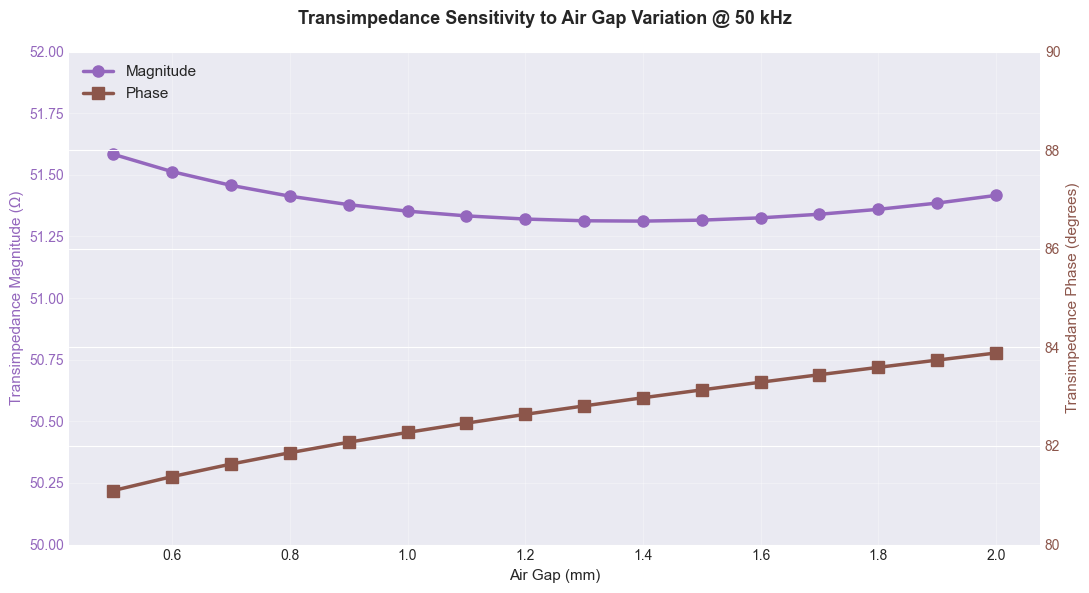

✓ PDF saved: plots_pdf\section_7_1_transimpedance_vs_airgap.pdf


WindowsPath('plots_pdf/section_7_1_transimpedance_vs_airgap.pdf')

In [ ]:
# Sweep drive/sense pole gaps and calculate transimpedance at fixed 50 kHz
import copy
from magnetoelasticsensor.permeance import calculate_effective_permeance, calculate_equivalent_permeance, cross_leakage_u_parameter

drive_gap_sweep_mm = np.linspace(0.5, 2.0, 16)  # Drive pole gap [mm]
sense_gap_sweep_mm = np.linspace(0.5, 2.0, 16)  # Sense pole gap [mm]
transimpedance_vs_ag = []
phase_vs_ag = []

# Get nominal frequency index (50 kHz)
nominal_freq_idx = 2  # 50 kHz is at index 2 in the frequencies array

for drive_gap_mm, sense_gap_mm in zip(drive_gap_sweep_mm, sense_gap_sweep_mm):
    # Geometry is unchanged for this sweep; air gaps are passed directly to the model
    geom_ag = copy.deepcopy(DEFAULT_SENSOR_GEOMETRY)
    
    # Calculate air gap permeances for this gap pair
    ag_model = AirGapPermeanceModel(geom_ag)
    ag_sense, ag_drive = ag_model.calculate_air_gap_permeance(
        drive_pole_gap=drive_gap_mm * 1e-3,
        sense_pole_gap=sense_gap_mm * 1e-3,
    )
    
    # Calculate target permeance at 50 kHz for this geometry
    u_target_ag = cross_leakage_u_parameter(
        dim_spagi=geom_ag.dim_spag.nominal,
        dim_dp=geom_ag.dim_dp.nominal,
        dim_spi=geom_ag.dim_sp.nominal,
    )
    
    # Calculate target permeance using the target_permeance module
    from magnetoelasticsensor.target_permeance import calculate_target_permeance
    p3_ag = calculate_target_permeance(
        geometry=geom_ag,
        u=u_target_ag,
        sigma_c=sigma_c,
        omega=omegas[nominal_freq_idx],  # 50 kHz
    )
    p3_ag = float(np.asarray(p3_ag).flat[0])
    
    # Calculate effective permeance (series: target + air gaps)
    p_eff_ag = calculate_effective_permeance(
        pt=p3_ag,
        p_gapd=ag_drive,
        p_gaps=ag_sense
    )
    
    # Calculate equivalent permeance (four-branch circuit)
    p_eq_ag = calculate_equivalent_permeance(
        p_core=baseline_permeance,
        p=p_eff_ag,
        p_sd=baseline_cross_leakage
    )
    
    # Calculate transimpedance
    Z_mag = calculate_transimpedance_magnitude(
        nd=nd,
        ns=ns,
        p_eq=p_eq_ag,
        omega=omegas[nominal_freq_idx],  # 50 kHz
        p3=p3_ag,
        p_sd=baseline_cross_leakage,
        p=p_eff_ag,
        epsilon=eta
    )
    
    Z_phase = calculate_transimpedance_phase(
        nd=nd,
        ns=ns,
        p_eq=p_eq_ag,
        omega=omegas[nominal_freq_idx],  # 50 kHz
        p3=p3_ag,
        p_sd=baseline_cross_leakage,
        p=p_eff_ag,
        epsilon=eta
    )
    
    transimpedance_vs_ag.append(Z_mag)
    phase_vs_ag.append(Z_phase)

transimpedance_vs_ag = np.array(transimpedance_vs_ag)
phase_vs_ag = np.array(phase_vs_ag)

# Create results dataframe
ag_sensitivity_df = pd.DataFrame({
    'Drive Gap (mm)': drive_gap_sweep_mm,
    'Sense Gap (mm)': sense_gap_sweep_mm,
    'Transimpedance Magnitude (Ω)': transimpedance_vs_ag,
    'Transimpedance Phase (rad)': phase_vs_ag,
    'Transimpedance Phase (deg)': np.degrees(phase_vs_ag),
})

print("DRIVE/SENSE GAP SENSITIVITY ANALYSIS @ 50 kHz")
print("=" * 70)
print(ag_sensitivity_df.to_string(index=False))
print("\n")

# Export to csv
csv_filename = "air_gap_sensitivity_50kHz.csv"
ag_sensitivity_df.to_csv(csv_filename, index=False)

# Calculate sensitivity (using drive gap sweep as independent variable)
mag_sensitivity = np.polyfit(drive_gap_sweep_mm, transimpedance_vs_ag, 1)[0]  # Ω/mm
phase_sensitivity = np.polyfit(drive_gap_sweep_mm, np.degrees(phase_vs_ag), 1)[0]  # deg/mm

print(f"Magnitude range:    {transimpedance_vs_ag.min():.3f} - {transimpedance_vs_ag.max():.3f} Ω")
print(f"Magnitude sensitivity: {mag_sensitivity:.3f} Ω/mm")
print(f"Phase range:        {np.degrees(phase_vs_ag).min():.1f}° - {np.degrees(phase_vs_ag).max():.1f}°")
print(f"Phase sensitivity:  {phase_sensitivity:.3f} °/mm")
print("\n")

# Plot with dual axis
fig, ax1 = plt.subplots(figsize=(11, 6))

# Magnitude on left y-axis
color = 'C4'
ax1.set_xlabel('Drive/Sense Pole Gap (mm)', fontsize=11)
ax1.set_ylabel('Transimpedance Magnitude (Ω)', color=color, fontsize=11)
line1 = ax1.plot(drive_gap_sweep_mm, transimpedance_vs_ag, 'o-', linewidth=2.5, markersize=8, 
                 color=color, label='Magnitude')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([50, 52])

# Phase on right y-axis
ax2 = ax1.twinx()
color = 'C5'
ax2.set_ylabel('Transimpedance Phase (degrees)', color=color, fontsize=11)
line2 = ax2.plot(drive_gap_sweep_mm, np.degrees(phase_vs_ag), 's-', linewidth=2.5, markersize=8, 
                 color=color, label='Phase')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim([80, 90])

# Title and legend
fig.suptitle('Transimpedance Sensitivity to Drive/Sense Gap Variation @ 50 kHz', fontsize=13, fontweight='bold')
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

# Save as PDF with smart filename
save_plot_pdf(fig, '7.1', 'Transimpedance_vs_DriveSenseGap')


## 7.2 Transimpedance vs. Target Permeability

This section analyzes how transimpedance changes when the target material permeability varies. Target permeability (μᵣ_target) depends on the ferromagnetic material composition and can vary due to material selection, temperature effects, or stress state. We sweep the target permeability from 55 to 65 at a fixed operating frequency (50 kHz) with the baseline air gap.

TARGET PERMEABILITY SENSITIVITY ANALYSIS @ 50 kHz
 Target Permeability (μᵣ)  Transimpedance Magnitude (Ω)  Transimpedance Phase (rad)  Transimpedance Phase (deg)
                     55.0                     50.952801                    1.440925                   82.558933
                     55.5                     50.990671                    1.440887                   82.556725
                     56.0                     51.028443                    1.440850                   82.554600
                     56.5                     51.066116                    1.440814                   82.552556
                     57.0                     51.103689                    1.440780                   82.550591
                     57.5                     51.141160                    1.440747                   82.548704
                     58.0                     51.178529                    1.440715                   82.546893
                     58.5                     51.21579

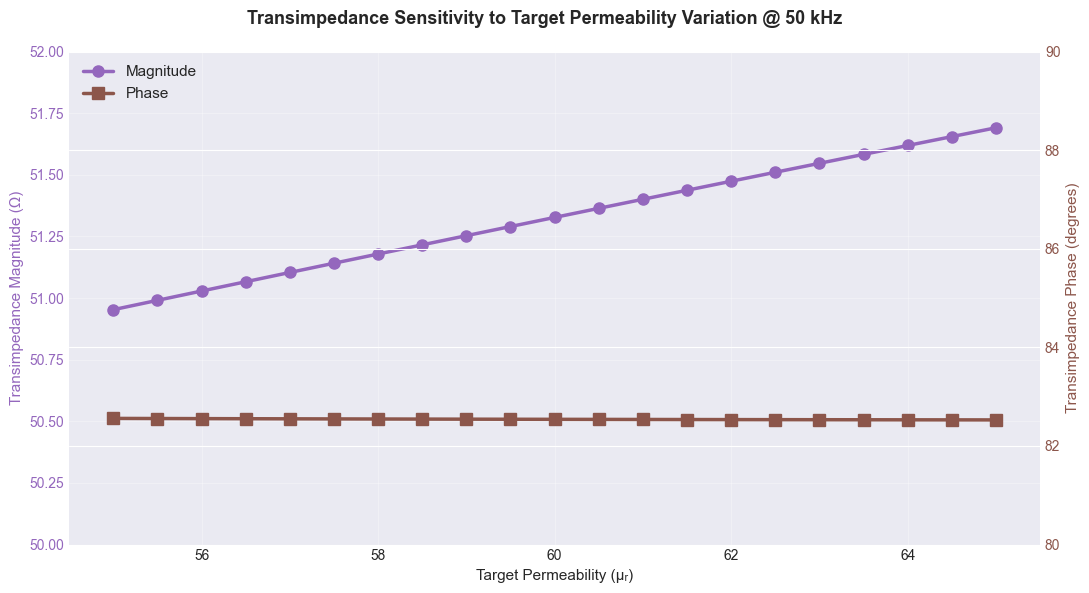

✓ PDF saved: plots_pdf\section_7_2_transimpedance_vs_targetpermeability.pdf


WindowsPath('plots_pdf/section_7_2_transimpedance_vs_targetpermeability.pdf')

In [17]:
# Sweep target permeability and calculate transimpedance at fixed 50 kHz
murt_sweep = np.linspace(55, 65, 21)  # Target relative permeability 
transimpedance_vs_murt = []
phase_vs_murt = []

for murt_val in murt_sweep:
    # Update geometry with new target permeability
    geom_murt = copy.deepcopy(DEFAULT_SENSOR_GEOMETRY)
    geom_murt.murt.nominal = murt_val
    
    # Recalculate target permeance at 50 kHz for this permeability
    u_target_murt = cross_leakage_u_parameter(
        dim_spagi=geom_murt.dim_spag.nominal,
        dim_dp=geom_murt.dim_dp.nominal,
        dim_spi=geom_murt.dim_sp.nominal,
    )
    
    # Calculate target permeance using the target_permeance module
    # Note: target permeance depends on target material permeability through skin depth
    p3_murt = calculate_target_permeance(
        geometry=geom_murt,
        u=u_target_murt,
        sigma_c=sigma_c,
        omega=omegas[nominal_freq_idx],  # 50 kHz
    )
    p3_murt = float(np.asarray(p3_murt).flat[0])
    
    # Calculate effective permeance (series: target + air gaps)
    # Use baseline air gaps (no change in geometry except murt)
    p_eff_murt = calculate_effective_permeance(
        pt=p3_murt,
        p_gapd=p_gap_drive,
        p_gaps=p_gap_sense
    )
    
    # Calculate equivalent permeance (four-branch circuit)
    p_eq_murt = calculate_equivalent_permeance(
        p_core=baseline_permeance,
        p=p_eff_murt,
        p_sd=baseline_cross_leakage
    )
    
    # Calculate transimpedance
    Z_mag = calculate_transimpedance_magnitude(
        nd=nd,
        ns=ns,
        p_eq=p_eq_murt,
        omega=omegas[nominal_freq_idx],  # 50 kHz
        p3=p3_murt,
        p_sd=baseline_cross_leakage,
        p=p_eff_murt,
        epsilon=eta
    )
    
    Z_phase = calculate_transimpedance_phase(
        nd=nd,
        ns=ns,
        p_eq=p_eq_murt,
        omega=omegas[nominal_freq_idx],  # 50 kHz
        p3=p3_murt,
        p_sd=baseline_cross_leakage,
        p=p_eff_murt,
        epsilon=eta
    )
    
    transimpedance_vs_murt.append(Z_mag)
    phase_vs_murt.append(Z_phase)

transimpedance_vs_murt = np.array(transimpedance_vs_murt)
phase_vs_murt = np.array(phase_vs_murt)

# Create results dataframe
murt_sensitivity_df = pd.DataFrame({
    'Target Permeability (μᵣ)': murt_sweep,
    'Transimpedance Magnitude (Ω)': transimpedance_vs_murt,
    'Transimpedance Phase (rad)': phase_vs_murt,
    'Transimpedance Phase (deg)': np.degrees(phase_vs_murt),
})

print("TARGET PERMEABILITY SENSITIVITY ANALYSIS @ 50 kHz")
print("=" * 70)
print(murt_sensitivity_df.to_string(index=False))
print("\n")

# Calculate sensitivity
mag_sensitivity_murt = np.polyfit(murt_sweep, transimpedance_vs_murt, 1)[0]  # Ω/unit
phase_sensitivity_murt = np.polyfit(murt_sweep, np.degrees(phase_vs_murt), 1)[0]  # deg/unit

print(f"Magnitude range:    {transimpedance_vs_murt.min():.3f} - {transimpedance_vs_murt.max():.3f} Ω")
print(f"Magnitude sensitivity: {mag_sensitivity_murt:.6f} Ω/μᵣ")
print(f"Phase range:        {np.degrees(phase_vs_murt).min():.1f}° - {np.degrees(phase_vs_murt).max():.1f}°")
print(f"Phase sensitivity:  {phase_sensitivity_murt:.6f} °/μᵣ")
print("\n")

# Plot with dual axis
fig, ax1 = plt.subplots(figsize=(11, 6))

# Magnitude on left y-axis
color = 'C4'
ax1.set_xlabel('Target Permeability (μᵣ)', fontsize=11)
ax1.set_ylabel('Transimpedance Magnitude (Ω)', color=color, fontsize=11)
line1 = ax1.plot(murt_sweep, transimpedance_vs_murt, 'o-', linewidth=2.5, markersize=8, 
                 color=color, label='Magnitude')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([50, 52])

# Phase on right y-axis
ax2 = ax1.twinx()
color = 'C5'
ax2.set_ylabel('Transimpedance Phase (degrees)', color=color, fontsize=11)
line2 = ax2.plot(murt_sweep, np.degrees(phase_vs_murt), 's-', linewidth=2.5, markersize=8, 
                 color=color, label='Phase')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim([80, 90])

# Title and legend
fig.suptitle('Transimpedance Sensitivity to Target Permeability Variation @ 50 kHz', fontsize=13, fontweight='bold')
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

# Save as PDF with smart filename
save_plot_pdf(fig, '7.2', 'Transimpedance_vs_TargetPermeability')
